In [1]:
import sys

import matplotlib.pyplot as plt
import torch
import torchaudio

from authtransforms.pipeline import Compose, OneOf, SomeOf
from authtransforms.transforms import (
    AddGaussianNoise,
    Normalize,
    RandomApply,
    RandomClip,
    RandomGain,
    RandomPitchShift,
    RandomSpeedChange,
    TimeShift,
    ToMono,
)
from authtransforms.utils import audio_info, compare_audio, compare_play, plot_audio,play_audio


In [2]:
from pathlib import Path

PROJECT_ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path.cwd().parent

audio_path = PROJECT_ROOT / "sample-audio-multilingual/english/real/121_127105_000007_000004.wav"
noise_dir = None

audio, sample_rate = torchaudio.load(audio_path)
print(f"Loaded: {audio_path}")
audio_info(audio, sample_rate, label="Original")


Loaded: /Users/uvieea/Documents/development/authtransforms/sample-audio-multilingual/english/real/121_127105_000007_000004.wav
[Original]
  Shape      : (1, 184080)
  Channels   : 1
  Sample rate: 24000 Hz
  Duration   : 7.670 s  (184080 samples)
  Peak       : 0.4513
  RMS        : 0.0446  (-27.0 dBFS)
  dtype      : torch.float32


/Users/uvieea/Library/Caches/pypoetry/virtualenvs/authtransforms-WaSjjtAv-py3.13/lib/python3.13/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [3]:
tfm = RandomClip(sample_rate=sample_rate, clip_length=sample_rate * 5)

In [4]:

augmented = tfm(audio)
audio_info(augmented, sample_rate, label="Augmented")


[Augmented]
  Shape      : (1, 112800)
  Channels   : 1
  Sample rate: 24000 Hz
  Duration   : 4.700 s  (112800 samples)
  Peak       : 0.4372
  RMS        : 0.0434  (-27.3 dBFS)
  dtype      : torch.float32


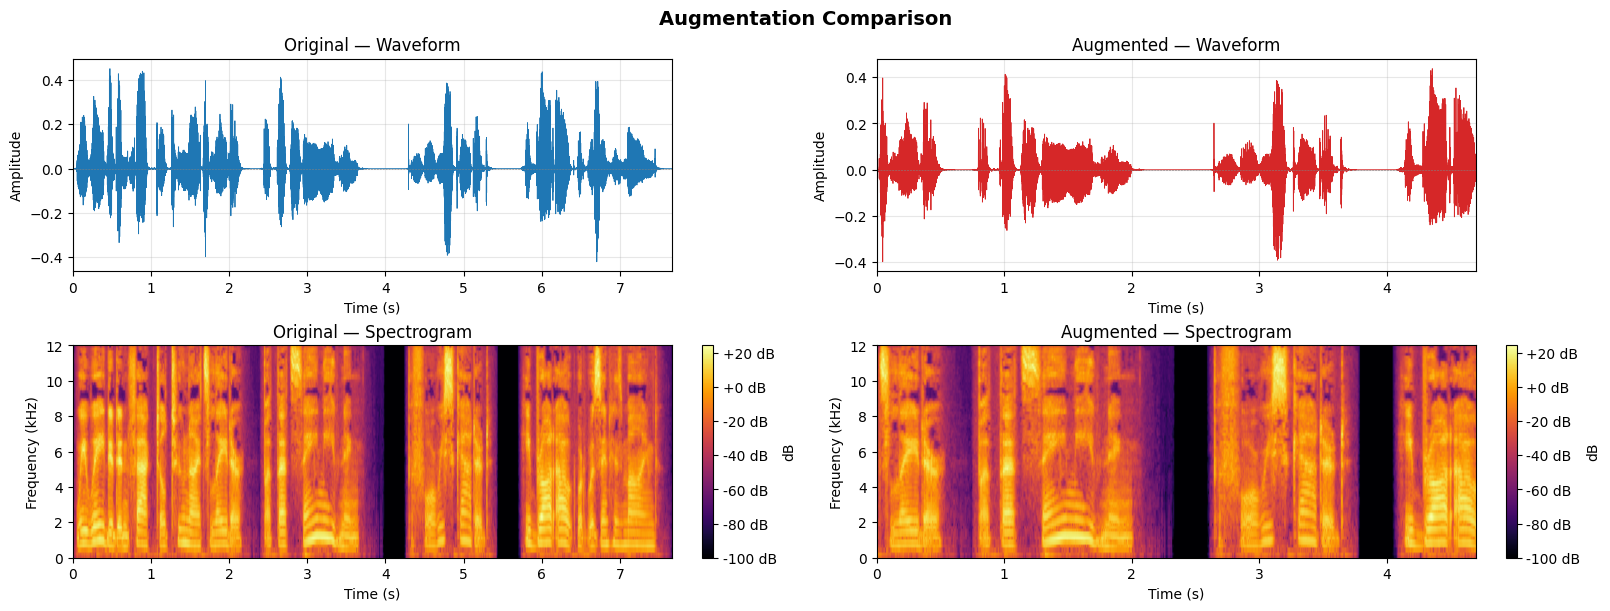

In [5]:

fig = compare_audio(
    audio,
    augmented,
    sample_rate,
    title_before="Original",
    title_after="Augmented",
)
plt.show()

In [6]:
play_audio(audio, sample_rate, label="Original")

/Users/uvieea/Library/Caches/pypoetry/virtualenvs/authtransforms-WaSjjtAv-py3.13/lib/python3.13/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(


In [7]:
play_audio(augmented, sample_rate, label="Original")

/Users/uvieea/Library/Caches/pypoetry/virtualenvs/authtransforms-WaSjjtAv-py3.13/lib/python3.13/site-packages/torchaudio/_backend/utils.py:337: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder
  warnings.warn(
